Task A

In [1]:
import pandas as pd

# 1. 读取数据
df = pd.read_csv("p1_communes.csv")

# 2. 维度
print(df.shape)

# 3. 前几行
df.head()

# 4. index + columns
print(df.index)
print(df.columns.tolist())

# 5. 数据类型
df.dtypes

# 6. 缺失值检查
df.isnull().sum()

df[df.isnull().any(axis=1)]

# 7. 如果有缺失值 → 删除
df = df.dropna()

(2202, 17)
RangeIndex(start=0, stop=2202, step=1)
['Canton', 'Commune', 'Language', 'Residents', 'Population density per km²', '0-19 years', '20-64 years', '65 years or over', 'Private households', 'Surface area in km²', 'Settlement area', 'Agricultural area', 'Wooded area', 'Unproductive area', 'East coordinate', 'North coordinate', 'Elevation']


Task B

In [2]:
# mean / min / max
df.describe().loc[['mean', 'min', 'max']]

# top 10 communes in population
top10 = df.sort_values(by='Residents', ascending=False).head(10)
top10[['Commune', 'Residents']]

bottom10 = df.sort_values(by='Residents').head(10)
bottom10[['Commune', 'Residents']]

for canton, group in df.groupby('Canton'):
    group.to_csv(f"{canton}.csv", index=False)

In [3]:
# canton density
canton_density = df.groupby('Canton').apply(
    lambda x: x['Residents'].sum() / x['Surface area in km²'].sum()
)

canton_density = canton_density.sort_values(ascending=False)
canton_density

/var/folders/j4/9_ylvq4j5v90dzpybklg93dc0000gn/T/ipykernel_16713/149020403.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  canton_density = df.groupby('Canton').apply(


Canton
BS    5271.069012
GE    2031.893255
ZH     948.443099
ZG     612.265881
BL     556.593969
AG     486.145498
SO     345.618319
TG     320.320701
LU     286.577848
VD     283.275259
SH     274.989938
SG     260.210650
NE     249.037193
AR     227.450173
FR     201.503947
SZ     186.964795
NW     179.095881
BE     177.054876
TI     131.670991
AI      93.605056
JU      87.558884
OW      78.733719
VS      65.977584
GL      59.355076
UR      34.457223
GR      29.047582
dtype: float64

In [4]:
df['working_majority'] = df['20-64 years'] > 50

result = df.groupby('Canton')['working_majority'].sum()
result

Canton
AG    210
AI      6
AR     20
BE    339
BL     86
BS      3
FR    131
GE     45
GL      3
GR    100
JU     53
LU     82
NE     30
NW     11
OW      7
SG     77
SH     26
SO    109
SZ     29
TG     80
TI    113
UR     20
VD    309
VS    124
ZG     11
ZH    158
Name: working_majority, dtype: int64

In [5]:
elevation_range = df.groupby('Canton')['Elevation'].agg(lambda x: x.max() - x.min())

top5 = elevation_range.sort_values(ascending=False).head(5)
top5

Canton
VS    2610
TI    2044
BE    2025
GR    2017
UR    1871
Name: Elevation, dtype: int64

Task C

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

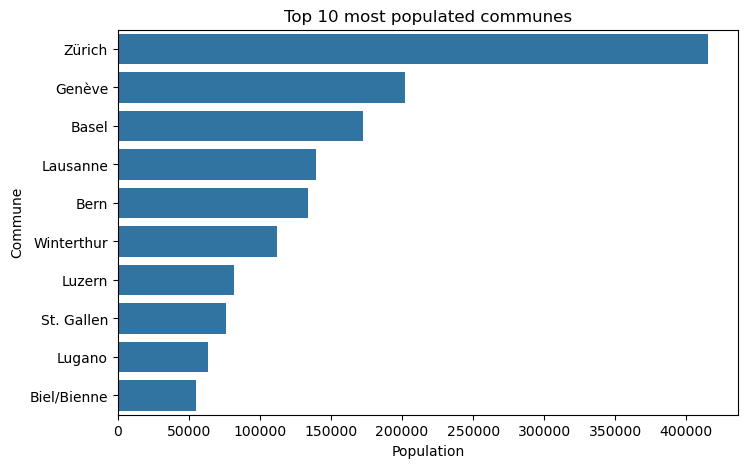

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(data=top10, y='Commune', x='Residents')
plt.title("Top 10 most populated communes")
plt.xlabel("Population")
plt.ylabel("Commune")
plt.show()

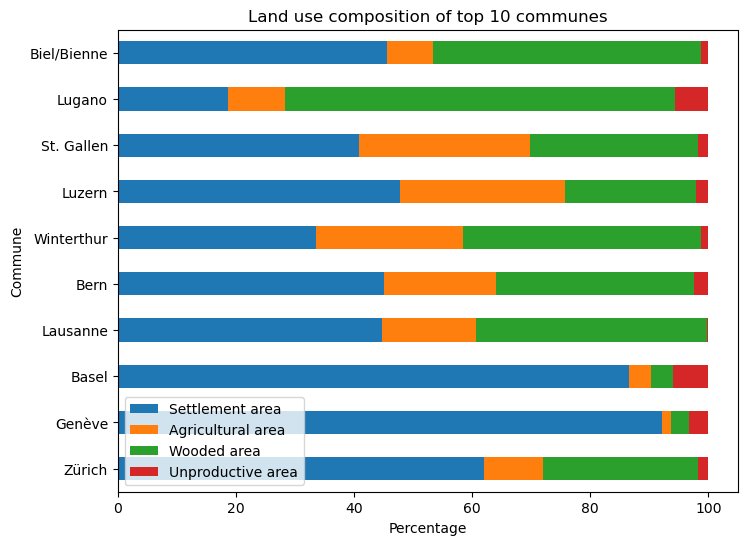

In [8]:
areas = ['Settlement area', 'Agricultural area', 'Wooded area', 'Unproductive area']

top10_area = top10.set_index('Commune')[areas]

top10_area.plot(kind='barh', stacked=True, figsize=(8,6))

plt.title("Land use composition of top 10 communes")
plt.xlabel("Percentage")
plt.ylabel("Commune")
plt.legend()
plt.show()

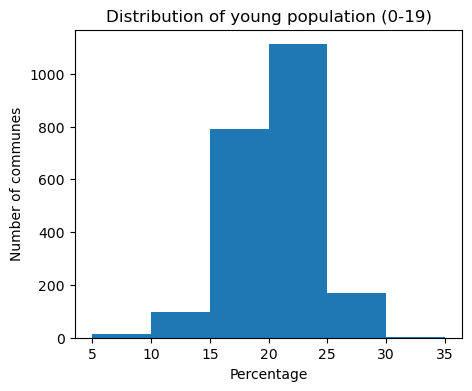

In [9]:
bins = [5,10,15,20,25,30,35]

plt.figure(figsize=(5,4))
plt.hist(df['0-19 years'], bins=bins)

plt.title("Distribution of young population (0-19)")
plt.xlabel("Percentage")
plt.ylabel("Number of communes")
plt.show()

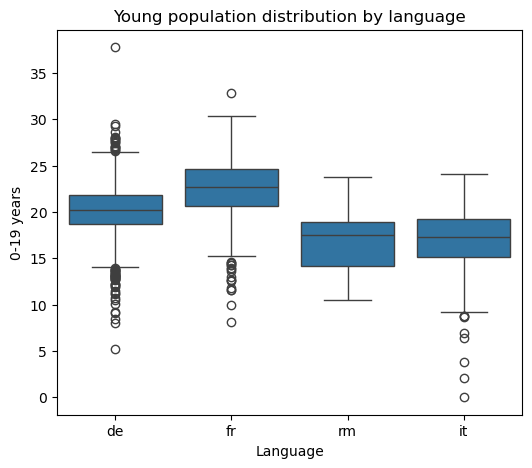

In [10]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='Language', y='0-19 years')

plt.title("Young population distribution by language")
plt.show()

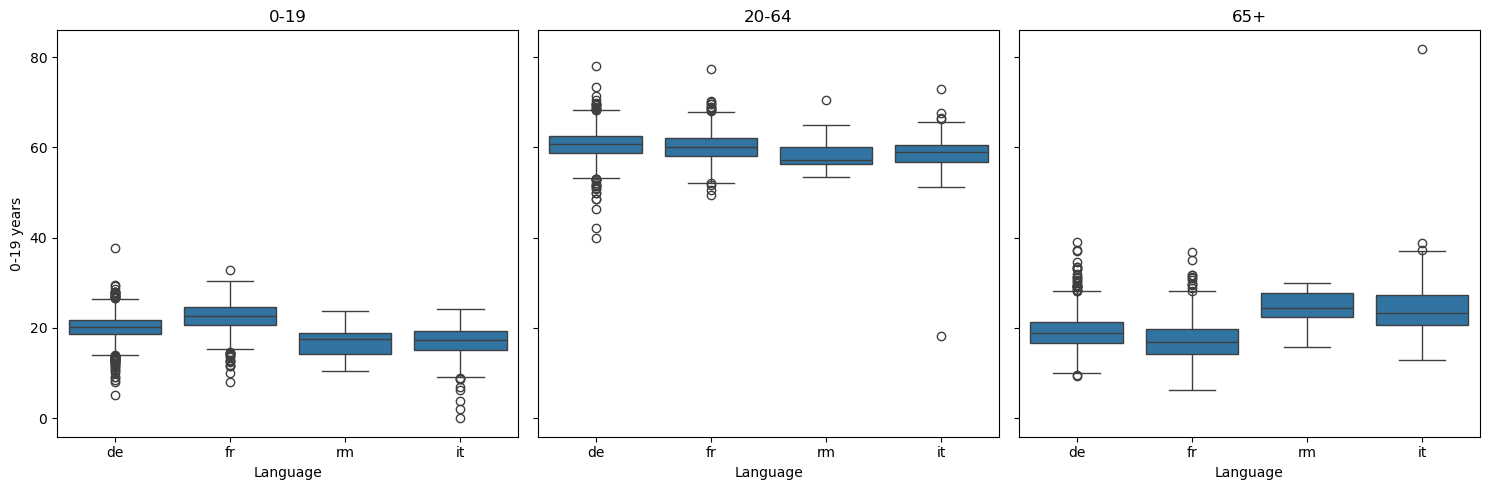

In [11]:
fig, axes = plt.subplots(1,3, figsize=(15,5), sharey=True)

sns.boxplot(data=df, x='Language', y='0-19 years', ax=axes[0])
axes[0].set_title("0-19")

sns.boxplot(data=df, x='Language', y='20-64 years', ax=axes[1])
axes[1].set_title("20-64")

sns.boxplot(data=df, x='Language', y='65 years or over', ax=axes[2])
axes[2].set_title("65+")

plt.tight_layout()
plt.show()

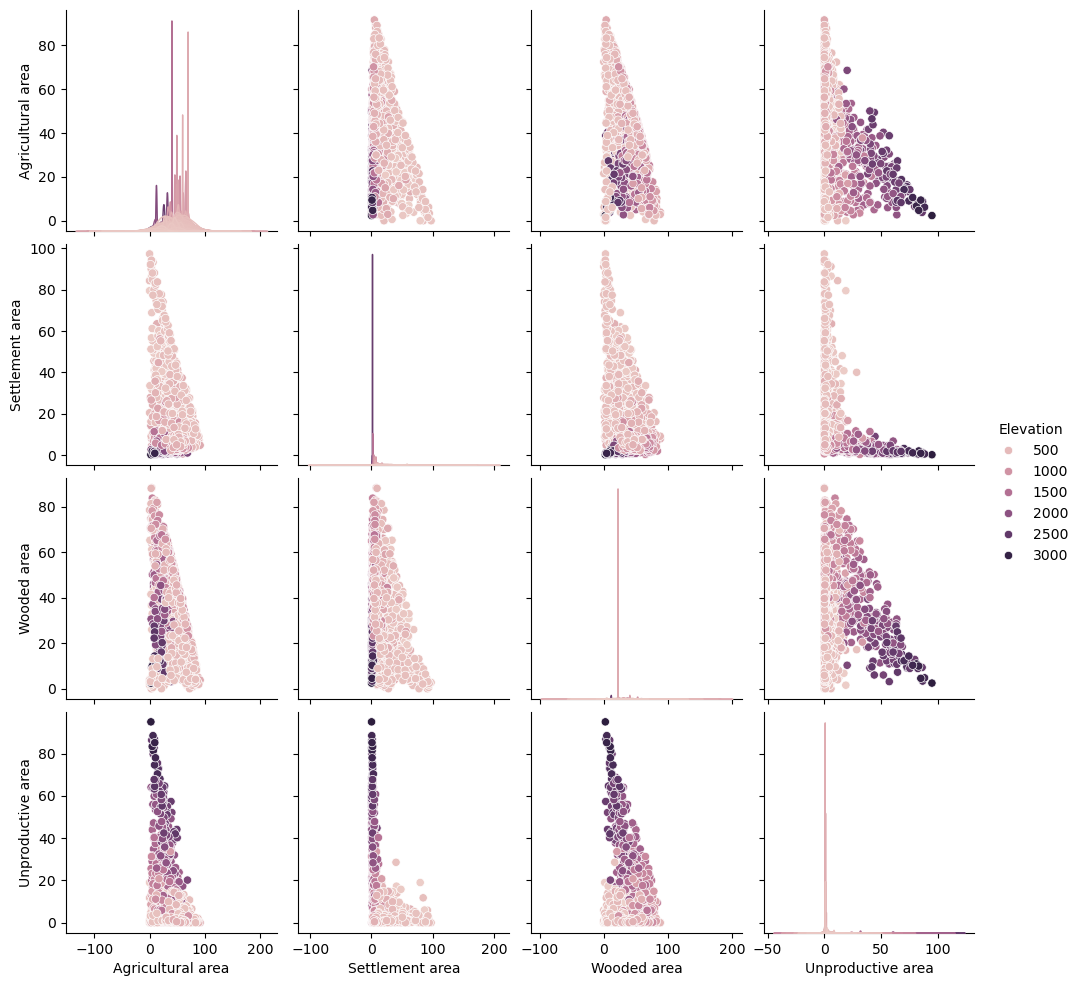

In [12]:
sns.pairplot(
    df,
    vars=['Agricultural area', 'Settlement area', 'Wooded area', 'Unproductive area'],
    hue='Elevation'
)

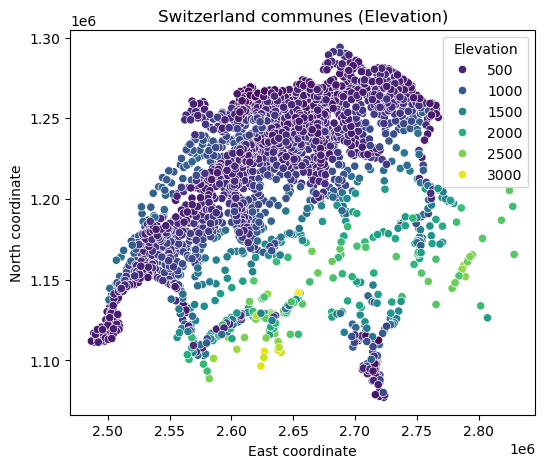

In [13]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='East coordinate',
    y='North coordinate',
    hue='Elevation',
    palette='viridis'
)

plt.title("Switzerland communes (Elevation)")
plt.show()

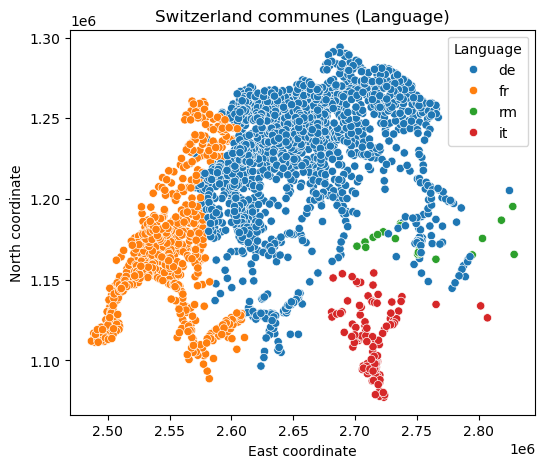

In [14]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='East coordinate',
    y='North coordinate',
    hue='Language'
)

plt.title("Switzerland communes (Language)")
plt.show()

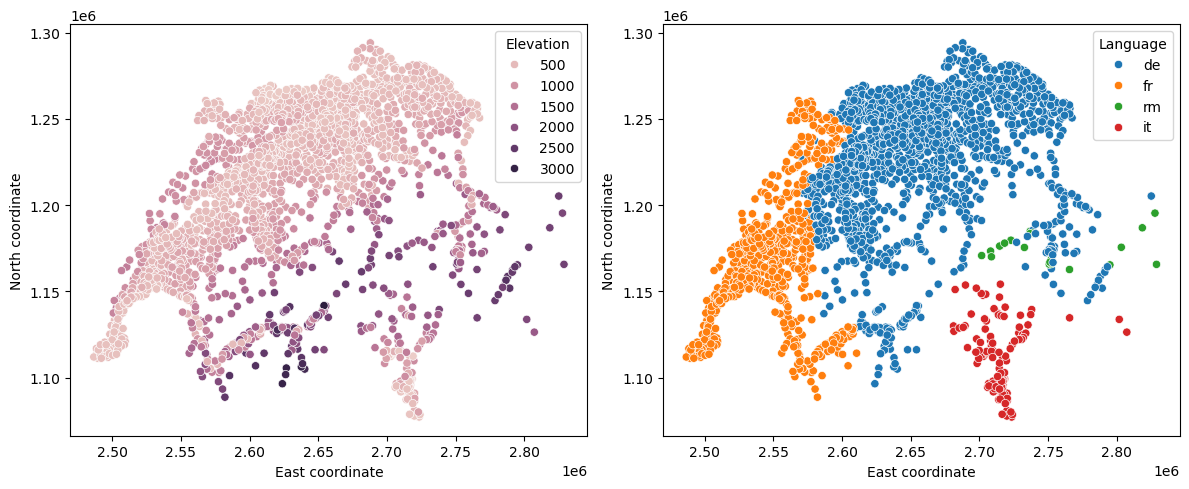

In [15]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.scatterplot(data=df, x='East coordinate', y='North coordinate',
                hue='Elevation', ax=axes[0])

sns.scatterplot(data=df, x='East coordinate', y='North coordinate',
                hue='Language', ax=axes[1])

plt.tight_layout()
plt.show()

Task D

In [17]:
high = df[df['Elevation'] > 2000]

prob = (high['Canton'] == 'VS').mean()

prob

0.5104166666666666

Task E

In [18]:
matrix = pd.crosstab(df['Commune'], df['Canton'])

# 转成 0/1
matrix = (matrix > 0).astype(int)

matrix.head()

Canton,AG,AI,AR,BE,BL,BS,FR,GE,GL,GR,...,SH,SO,SZ,TG,TI,UR,VD,VS,ZG,ZH
Commune,,,,,,,,,,,,,,,,,,,,,
Aadorf,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Aarau,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aarberg,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aarburg,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aarwangen,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
